# Processing Workflows

While the descriptions from the first notebook are nice, they're not research data or archival metadata.

This next section details a workflow that will process your materials into a structured format that can be used for research or library systems. This is an example that can be adapted to your specific needs.

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1-wksvuqBUv8qq2mLJ8EbbluStjyvXIp7#scrollTo=OsonjvCPSjIr)  

# Select Model

There are many open-source models for OCR or HTR available. The Qwen family (q-when) of models has led the way as a tool to extract handwritten text. There are many models adapted from [Qwen](https://huggingface.co/Qwen), such as the [Nanonets OCR model](https://huggingface.co/nanonets/Nanonets-OCR-s), which preserves structured information like tables or forms.

For this workshop, we'll be using the newest model "Qwen/Qwen3-VL-8B-Instruct" 

In [2]:
model = "Qwen/Qwen3-VL-8B-Instruct"
base_url = "https://glw30r2npdvyvzho.us-east-1.aws.endpoints.huggingface.cloud/v1/"
api_key = (
    "not needed for this workshop!"  # But you might need one for your own projects
)

## Langchain 

- why we're using it, what it does 
- how the code is slightly different 

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=model, base_url=base_url, api_key=api_key)
llm.invoke("hi!")

AIMessage(content='Hi! 😊 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 10, 'total_tokens': 22, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/Qwen3-VL-8B-Instruct', 'system_fingerprint': None, 'id': 'chatcmpl-nrrFuS', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--fa0dd497-a08b-44d2-a9f0-de24313cdb7a-0', usage_metadata={'input_tokens': 10, 'output_tokens': 12, 'total_tokens': 22, 'input_token_details': {}, 'output_token_details': {}})

In [ ]:
# Create a HumanMessage with content and image attribute
from langchain_core.messages import HumanMessage


class HumanMessageWithImage(HumanMessage):
    def __init__(self, content, image=None, **kwargs):
        super().__init__(content=content, **kwargs)
        self.image = image

# Workflow Requirements
- Input is the URL for a box manifest in EAP (other other IIIF collection)
- We need to predict individual items in the folder or box.
- We need to recognize the relevant entites (people, places, organizations) in each item in the context of the larger collection. For a legal case, for example, we only need entitle in the case as well as their relationship to the case (e.g. plaintiff, judge, victim).

# Strategy

- Extract the text of all individual images
- Use text and descriptions to predict individual items (a two-page letter, a 50-page memo...)
- Generate item-level research metadata

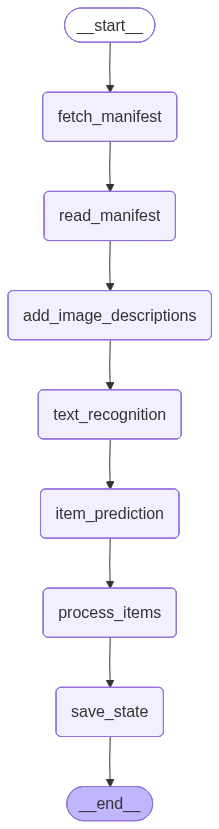

In [10]:
from IPython.display import Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining

from typing_extensions import TypedDict


class Box(TypedDict):  # Level: File in EAP
    box_manifest_uri: str
    box_manifest_data: dict
    box_metadata: dict
    box_summary: str
    people: list[str]
    places: list[str]
    organizations: list[str]
    image_urls: list[str]
    images: list[dict]
    item_grouping: list
    items: dict
    sample: int  # Process only first n images in the box

In [4]:
import json
import requests
from tqdm import tqdm
from typer import prompt
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


# Nodes
def fetch_manifest(state: Box) -> Box:
    header = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/11"
    }
    manifest = requests.get(state["box_manifest_uri"], headers=header)
    if manifest.status_code != 200:
        raise Exception(f"Error downloading manifest: {manifest.status_code}")
    print("Fetched manifest successfully!")
    return {"box_manifest_data": manifest.json()}


def read_manifest(state: Box) -> Box:
    images = []
    for canvas in state["box_manifest_data"]["sequences"][0]["canvases"]:
        for image in canvas["images"]:
            image_uri = image.get("resource", None).get("@id", None)
            if image_uri:
                images.append(image_uri)
    metadata = {}
    for item in state["box_manifest_data"]["metadata"]:
        metadata[item["label"]] = item["value"]
    print(f"Found {len(images)} images in manifest!!")
    return {
        "box_manifest_uri": state["box_manifest_uri"],
        "box_manifest_data": state["box_manifest_data"],
        "image_urls": images,
        "box_metadata": metadata,
    }


def add_image_descriptions(state: Box) -> Box:
    llm = ChatOpenAI(model=model, base_url=base_url, api_key=api_key)
    images = [{"image_url": url} for url in state["image_urls"]]
    for image in tqdm(images, desc="Adding descriptions to images"):
        prompt = """Describe the image for use as alt-text.\nUse the following metadata as context: \n"""
        for key, value in state["box_metadata"].items():
            prompt += f"- {key}: {value}\n"
        msg = HumanMessageWithImage(content=prompt, image=image["image_url"])
        result = llm.invoke([msg])
        image["description"] = result.content
    state["images"] = images
    return state


def text_recognition(state: Box) -> Box:
    """Extract text from images using OCR."""
    llm = ChatOpenAI(model=model, base_url=base_url, api_key=api_key)
    images = state["images"]
    for image in tqdm(images, desc="Extracting text from images"):
        prompt = "If printed or handwritten text is present in the image, extract text from the page. Do not add any text that isn't present in the image. Preserve reading order. Retain formatting as markdown."
        msg = HumanMessageWithImage(content=prompt, image=image["image_url"])
        result = llm.invoke([msg])
        image["markdown_text"] = result.content
    state["images"] = images
    return state


def item_prediction(state: Box) -> Box:
    llm = ChatOpenAI(model=model, base_url=base_url, api_key=api_key)
    images = state["images"]
    prompt = """Your are an archival processing assistant. You have descriptions and text from individual pages in a box. Each image is identified by an <image> tag. Group the images into groups that identify coherent items. For example, the images may be the front and back of the same page. Two pages may be the start and end of a letter. You may have images that start or end a folder. Return only a list of grouped images as JSON and your reaonsing. For example: {"items":[[1,2],[3],[4,5,6]], "reasoning:"..."}"""
    prompt += "\nUse the following metadata for context, particularly look for types of documents and document groupings (i.e. letters, folders, photographs):\n"
    for key, value in state["box_metadata"].items():
        prompt += f"- {key}: {value}\n"
    prompt += "\n\nHere are the image descriptions and text:\n\n"
    for i, image in enumerate(images):
        prompt += f"<image {i}>description: {image['description']}; text {image['markdown_text']}</image {i}>"
    msg = HumanMessage(content=prompt)
    result = llm.invoke([msg])
    # convert result content to dict
    if result:
        import json

        state["item_grouping"] = json.loads(result.content)
    return state


def process_items(state: Box) -> Box:
    item_grouping = state.get("item_grouping", None).get("items", [])
    images = state["images"]
    items = []
    for group in item_grouping:
        # pool text from images in the item
        item_texts = []
        for index in group:
            image = images[index]
            item_texts.append(
                f"<image {index}>description: {image['description']}; text {image['markdown_text']}</image {index}>"
            )

        prompt = """Your are an archival processing assistant. You are given the text or description from one or more images in an item. Provide an item-level description. Be sure to record entities, such as people, places and organizations, with context as yaml frontmatter."""
        prompt += "\n\nHere are the image descriptions and text:\n\n"
        prompt += "\n".join(item_texts)
        msg = HumanMessage(content=prompt)
        result = llm.invoke([msg])
        items.append(
            {
                "item_texts": item_texts,
                "item_description": result.content,
                "group": group,
            }
        )
    state["items"] = items
    return state


def save_state(state: Box) -> Box:
    box_id = (
        state["box_metadata"]
        .get("Identifier", "unknown_box")
        .replace(" ", "_")
        .replace("/", "_")
    )
    with open(f"{box_id}.json", "w") as f:
        json.dump(state, f, indent=4)
    print(f"Saved processed state to {box_id}.json")
    return state

In [5]:
from langgraph.graph import StateGraph, START, END

# Build workflow
builder = StateGraph(Box)
# Add nodes
builder.add_node("fetch_manifest", fetch_manifest)
builder.add_node("read_manifest", read_manifest)
builder.add_node("add_image_descriptions", add_image_descriptions)
builder.add_node("text_recognition", text_recognition)
builder.add_node("item_prediction", item_prediction)
builder.add_node("process_items", process_items)
builder.add_node("save_state", save_state)

# Add edges to connect nodes
builder.add_edge(START, "fetch_manifest")
builder.add_edge("fetch_manifest", "read_manifest")
builder.add_edge("read_manifest", "add_image_descriptions")
builder.add_edge("add_image_descriptions", "text_recognition")
builder.add_edge("text_recognition", "item_prediction")
builder.add_edge("item_prediction", "process_items")
builder.add_edge("process_items", "save_state")
builder.add_edge("save_state", END)
# Compile
graph = builder.compile()

In [ ]:
# Invoke

output = graph.invoke(
    {
        "box_manifest_uri": "https://eap.bl.uk/archive-file/EAP699-23-1/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP699-23-1/manifest"
    }
)
# TODO add start, end index for images in box

Fetched manifest successfully!

Found 4 images in manifest!!

Extracting text from images: 100%|██████████| 4/4 [00:00<00:00,  4.95it/s]


Saved processed state to EAP699_23_1.json

In [ ]:
from rich import print

for item in output["items"]:
    print(item["item_description"])

```yaml
---
title: "Photographs Documenting Life and Culture in Moldova"
description: "A collection of archival photographs capturing scenes and individuals from Romanian- and 
Russian-speaking communities in Moldova, Europe. The images reflect the region’s linguistic and cultural diversity,
featuring text in both Cyrillic and Latin scripts. Digitised by the Institute of the Cultural Heritage of the 
Academy of Sciences of Moldova as part of the Endangered Archives Programme, funded by Arcadia. These materials 
offer a visual record of daily life, traditions, and historical moments across Moldova."
date: "Unknown (digitised as part of EAP699/23/1)"
location: "Moldova, Europe"
language: ["Romanian", "Russian", "Cyrillic script", "Latin script"]
entities:
  - type: organization
    name: "Institute of the Cultural Heritage of the Academy of Sciences of Moldova"
    role: "Digitising institution"
  - type: program
    name: "Endangered Archives Programme"
    role: "Funding and digitisation initiative"
  - type: funder
    name: "Arcadia"
    role: "Funding body"
  - type: repository
    name: "British Library"
    role: "Hosting institution for EAP699/23/1"
  - type: region
    name: "Moldova"
    description: "Eastern European country with significant Romanian and Russian-speaking populations"
  - type: language
    name: "Romanian"
    context: "Official language of Moldova; appears in Latin script"
  - type: language
    name: "Russian"
    context: "Historically influential language in Moldova; appears in Cyrillic script"
  - type: archive_identifier
    name: "EAP699/23/1"
    context: "Endangered Archives Programme accession number"
  - type: url
    name: "https://eap.bl.uk/archive-file/EAP699-23-1"
    context: "Catalogue record for the collection"
---
```

## For evaluation section

In [13]:
import srsly 
evaluation_data = srsly.read_json("fmb_evaluation_data.json")

In [19]:
# Get manifest URIs from evaluation data
manifest_uris = [entry["manifest_uri"] for entry in evaluation_data.values()]
len(manifest_uris)

37

In [ ]:
for manifest in manifest_uris:
    output = graph.invoke(
        {
            "box_manifest_uri": manifest
        }
    )